# Archived weather processing notes

This is older weather-processing work kept for reference. It is not part of the main workflow.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
weather = pd.read_csv("weather_hourly_1.csv", skiprows = 3)

weather.head()


,time,temperature_2m (°F),rain (mm),precipitation (mm),apparent_temperature (°F),snowfall (cm),snow_depth (m),weather_code (wmo code),relative_humidity_2m (%),dew_point_2m (°F),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),wind_gusts_10m (mp/h),wind_direction_100m (°),wind_direction_10m (°),wind_speed_100m (mp/h),wind_speed_10m (mp/h)
0,2015-10-01T00:00,59.1,0.0,0.0,53.2,0.0,0.0,3,72,49.9,100,24,97,90,25.3,8,6,22.1,13.9
1,2015-10-01T01:00,58.5,0.0,0.0,52.4,0.0,0.0,3,70,48.8,100,18,98,97,25.1,9,8,21.3,13.5
2,2015-10-01T02:00,57.9,0.0,0.0,52.0,0.0,0.0,3,70,48.1,100,60,100,99,24.6,8,6,19.7,12.8
3,2015-10-01T03:00,57.9,0.0,0.0,52.0,0.0,0.0,3,69,47.8,100,54,97,100,25.1,11,8,19.6,12.7
4,2015-10-01T04:00,57.6,0.0,0.0,51.6,0.0,0.0,3,68,47.0,100,99,100,100,24.8,13,10,18.8,12.3


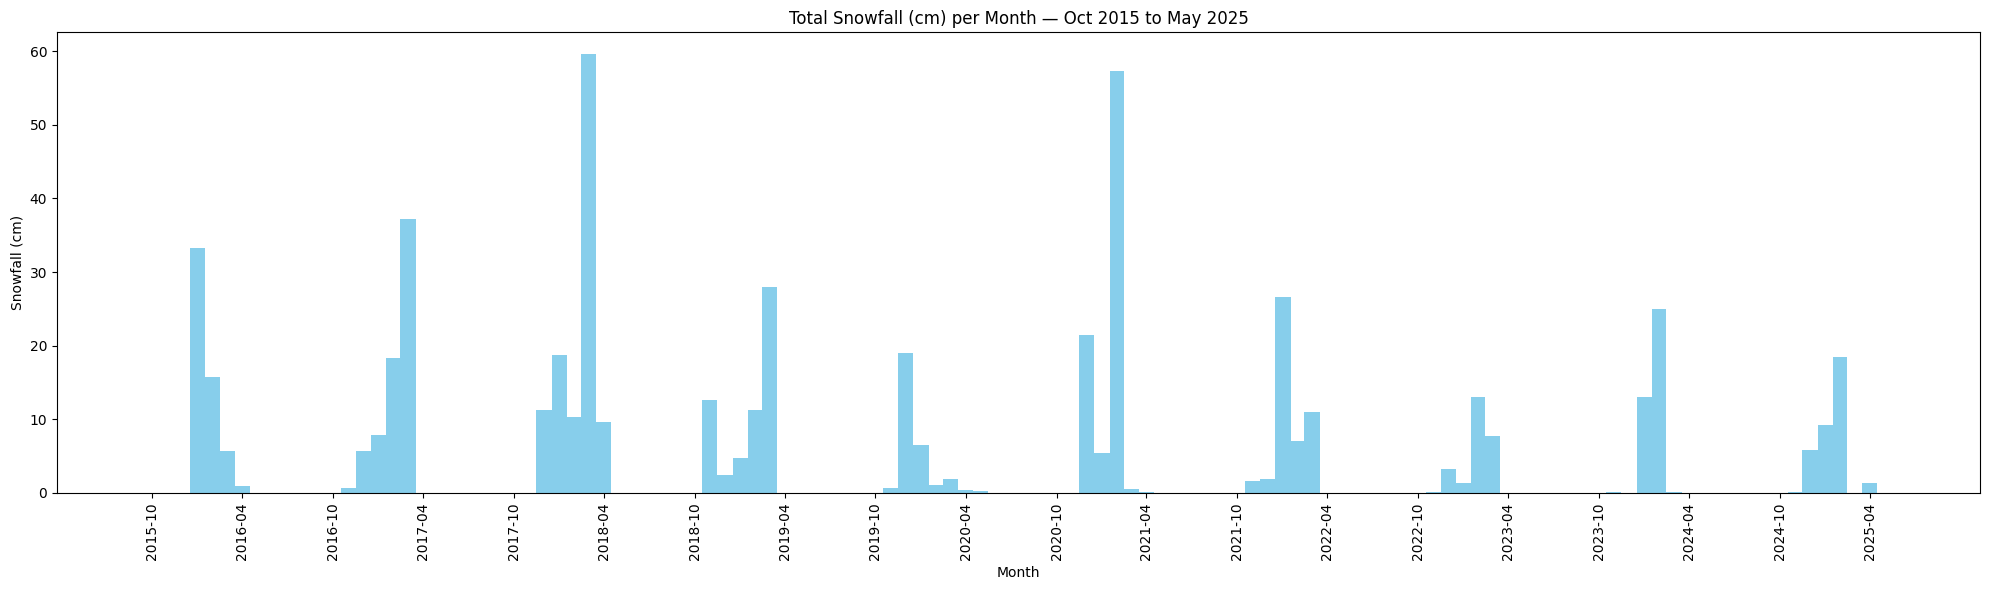

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure datetime and numeric columns
weather['time'] = pd.to_datetime(weather['time'], errors='coerce')
weather['snowfall (cm)'] = pd.to_numeric(weather['snowfall (cm)'], errors='coerce')

# Monthly bins from Oct 2015 to May 2025
bins = pd.date_range("2015-10-01", "2025-06-01", freq="MS")  # MS = month start

# Aggregate snowfall by month
snowfall_sum, _ = np.histogram(weather['time'], bins=bins, weights=weather['snowfall (cm)'])

# Compute bin centers for labeling
bin_centers = bins[:-1] + np.diff(bins)/2

# Plot
plt.figure(figsize=(20, 6))  # larger figure
plt.bar(bin_centers, snowfall_sum, width=np.diff(bins), align="center", color="skyblue")

# Format x-axis labels as "YYYY-MM"
# Show only every 6th month for readability
plt.xticks(bin_centers[::6], [d.strftime("%Y-%m") for d in bin_centers[::6]], rotation=90)
plt.title("Total Snowfall (cm) per Month — Oct 2015 to May 2025")
plt.xlabel("Month")
plt.ylabel("Snowfall (cm)")
plt.tight_layout()
plt.show()


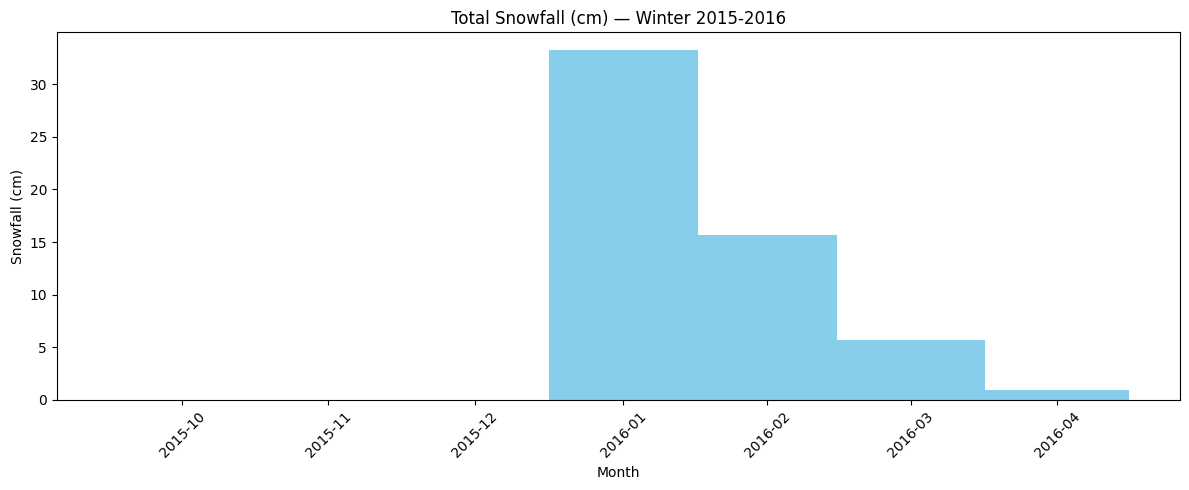

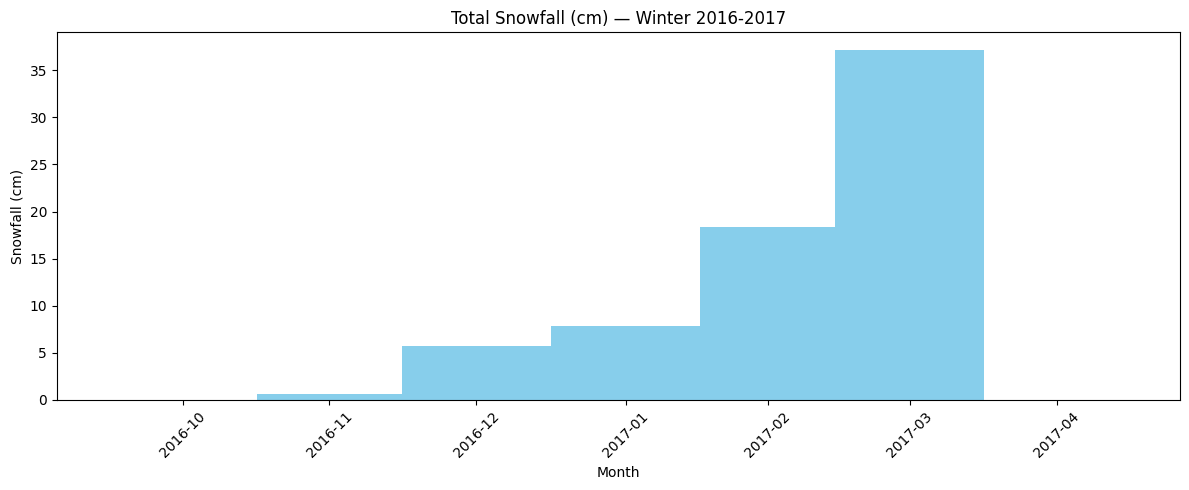

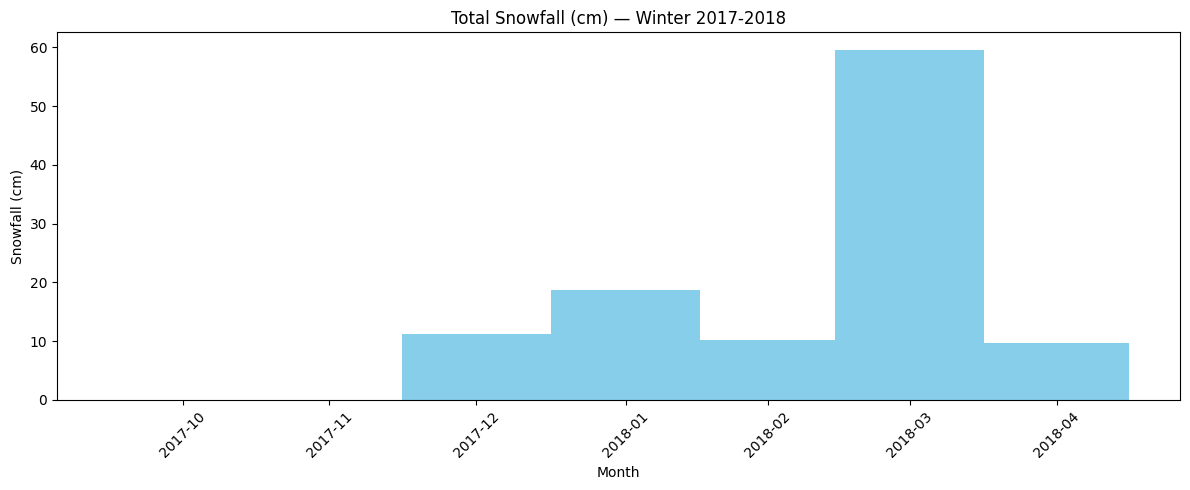

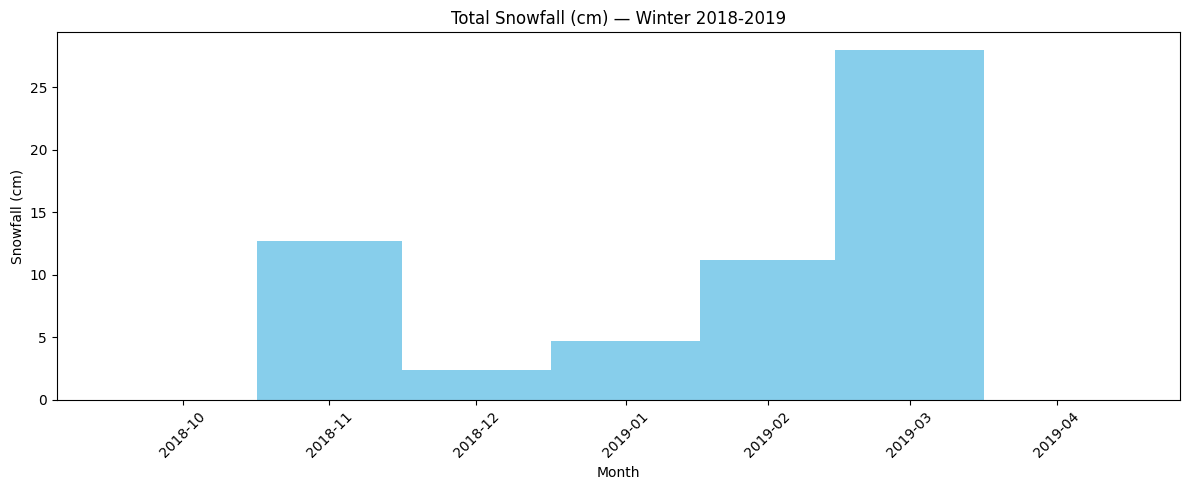

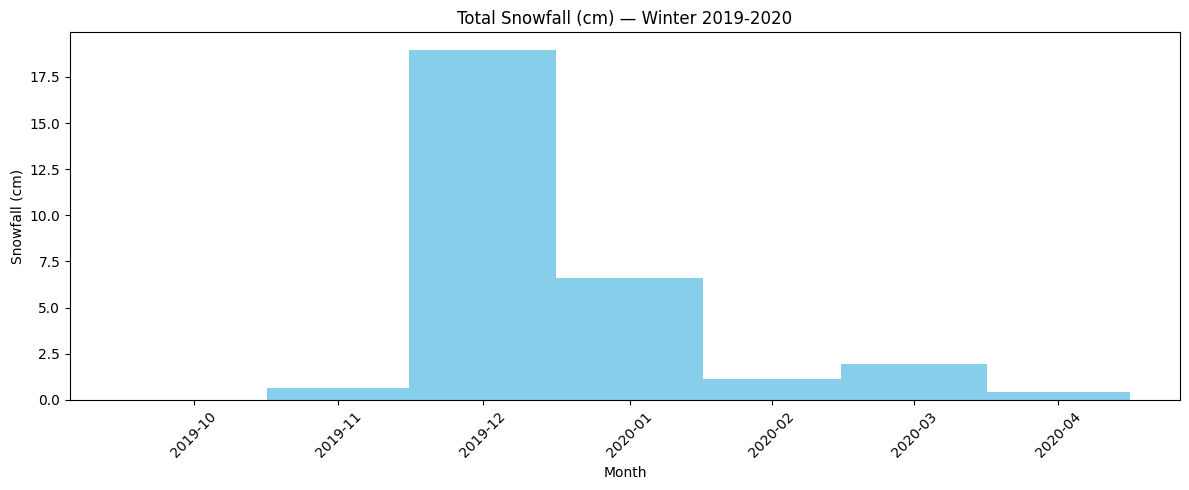

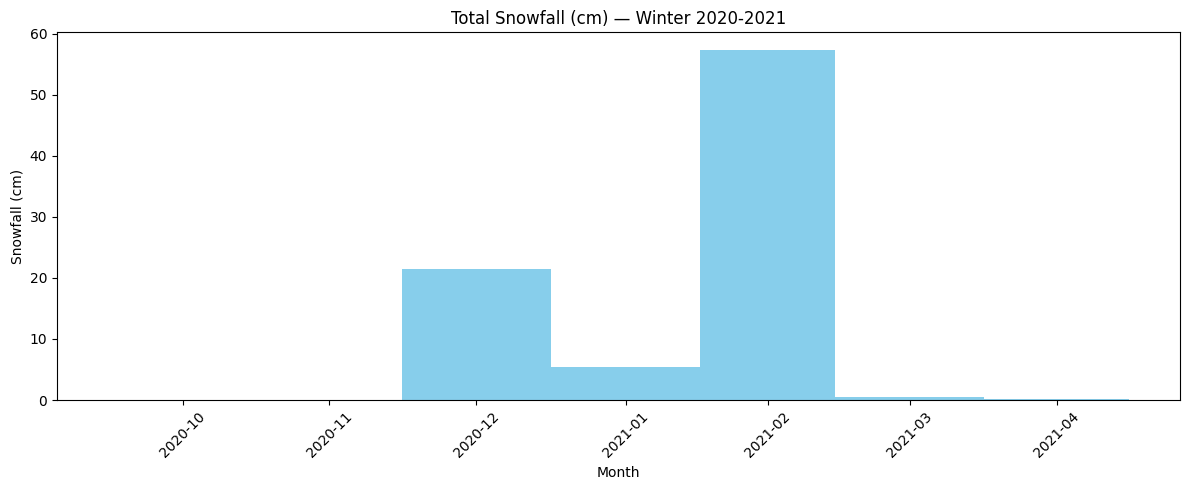

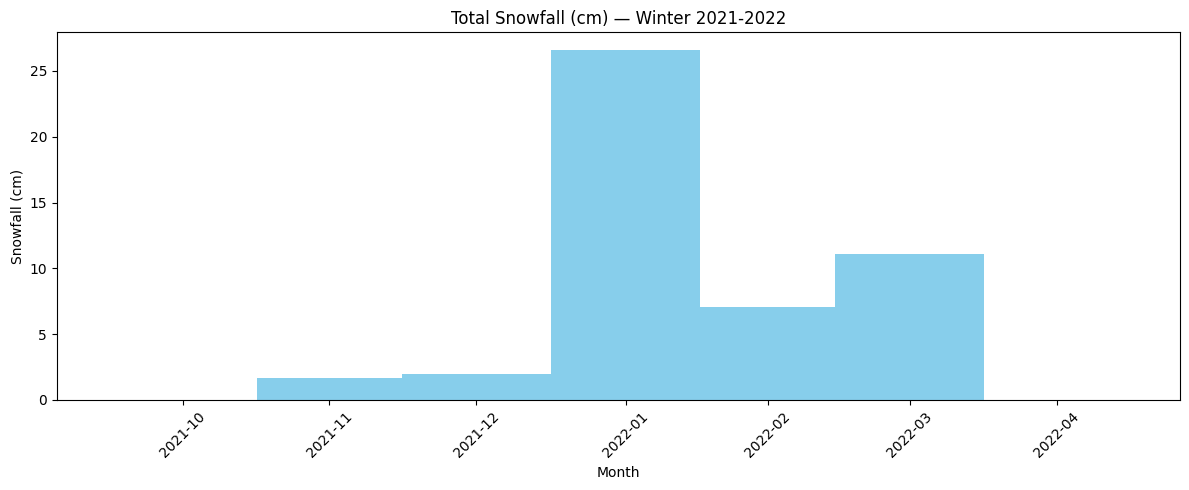

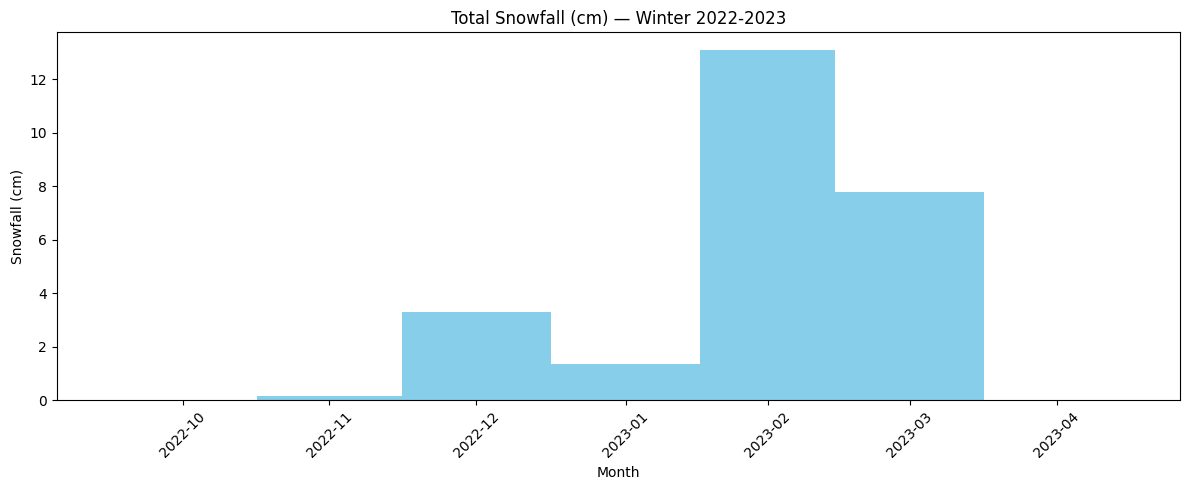

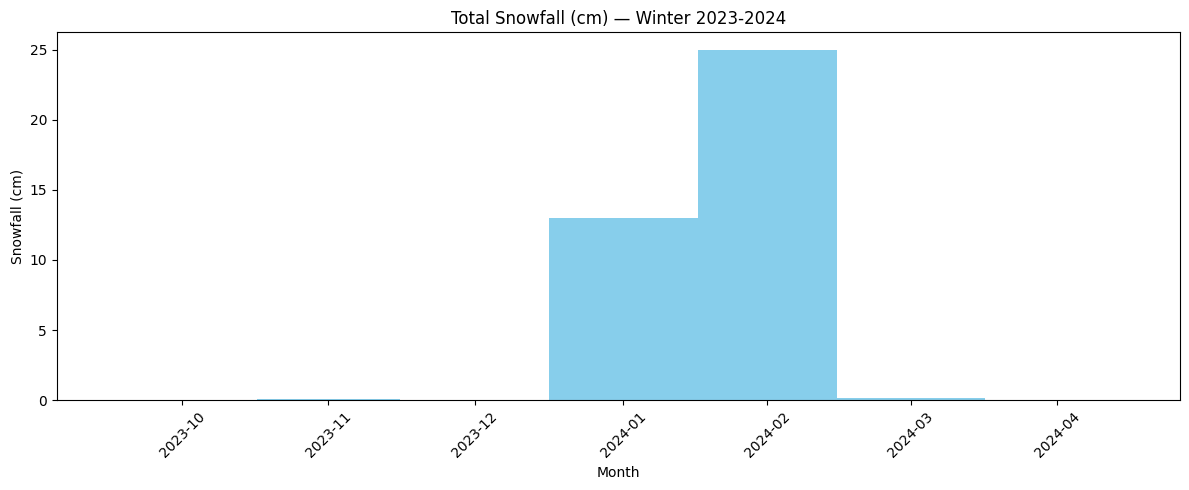

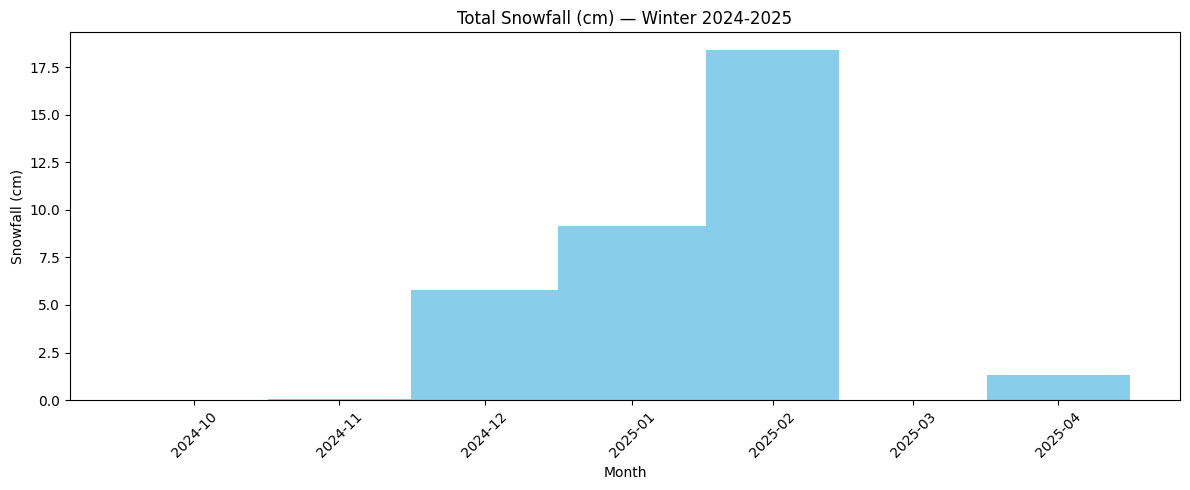

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure datetime and numeric columns
weather['time'] = pd.to_datetime(weather['time'], errors='coerce')
weather['snowfall (cm)'] = pd.to_numeric(weather['snowfall (cm)'], errors='coerce')

# Define seasons: winter 2015–2016 through winter 2024–2025
seasons = [(y-1, y) for y in range(2016, 2025+1)]  # (Oct Y-1 to Apr Y)

for start_year, end_year in seasons:
    start_date = pd.Timestamp(f"{start_year}-10-01")
    end_date = pd.Timestamp(f"{end_year}-05-01")
    
    # Filter snowfall in season
    mask = (weather['time'] >= start_date) & (weather['time'] < end_date)
    df_season = weather[mask].copy()
    
    # Monthly bins for this season
    bins = pd.date_range(start_date, end_date + pd.offsets.MonthEnd(0), freq="MS")
    
    # Aggregate snowfall by month
    snowfall_sum, _ = np.histogram(df_season['time'], bins=bins, weights=df_season['snowfall (cm)'])
    
    # Bin centers for plotting
    bin_centers = bins[:-1] + np.diff(bins)/2
    
    # Plot
    plt.figure(figsize=(12, 5))
    plt.bar(bin_centers, snowfall_sum, width=np.diff(bins), align="center", color="skyblue")
    plt.xticks(bin_centers, [d.strftime("%Y-%m") for d in bin_centers], rotation=45)
    plt.title(f"Total Snowfall (cm) — Winter {start_year}-{end_year}")
    plt.xlabel("Month")
    plt.ylabel("Snowfall (cm)")
    plt.tight_layout()
    plt.show()

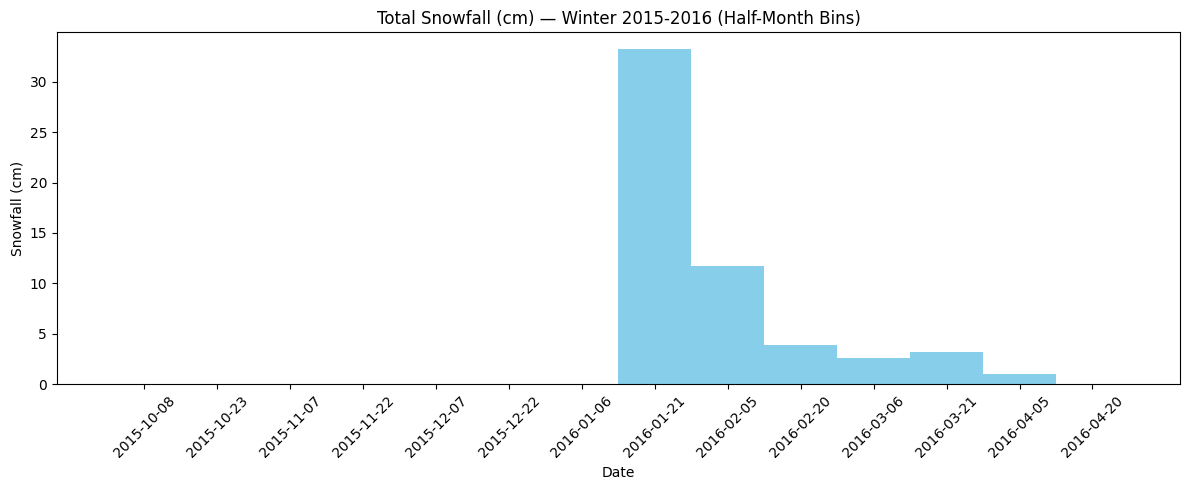

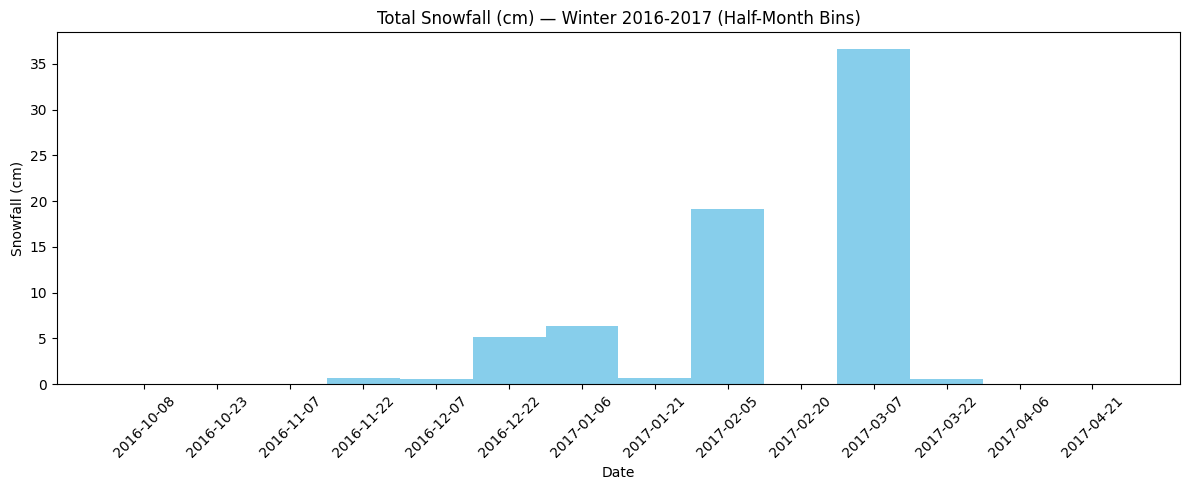

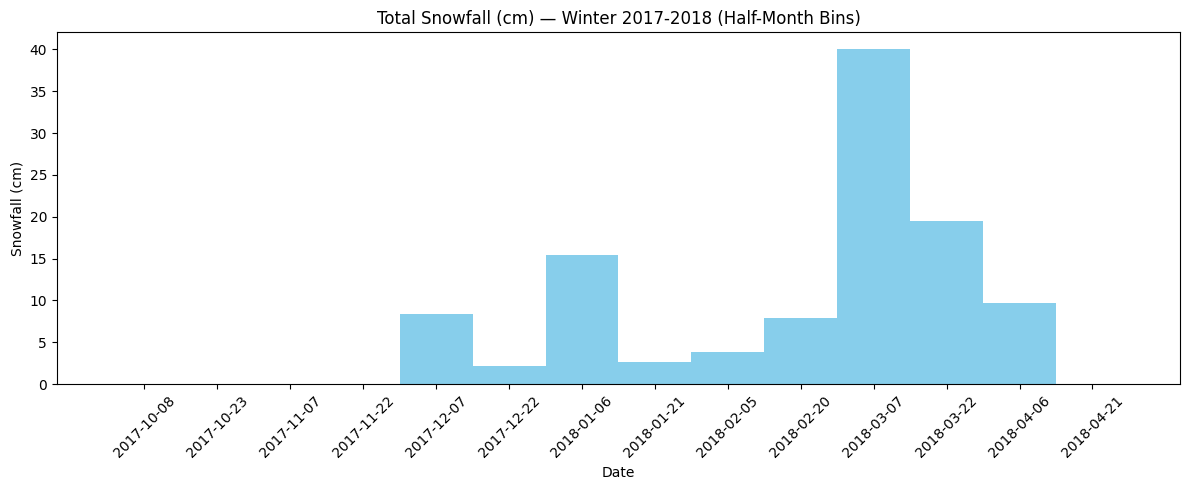

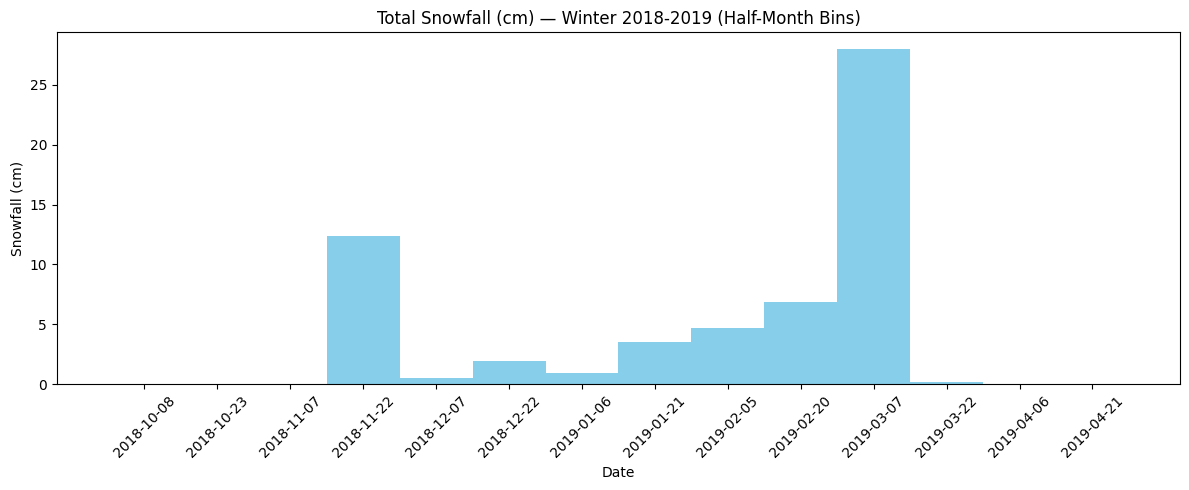

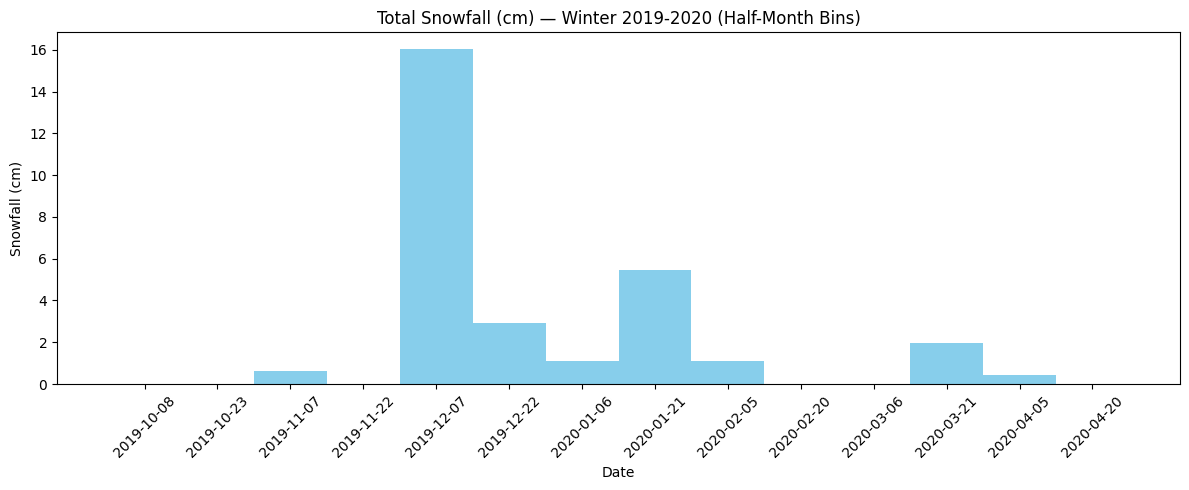

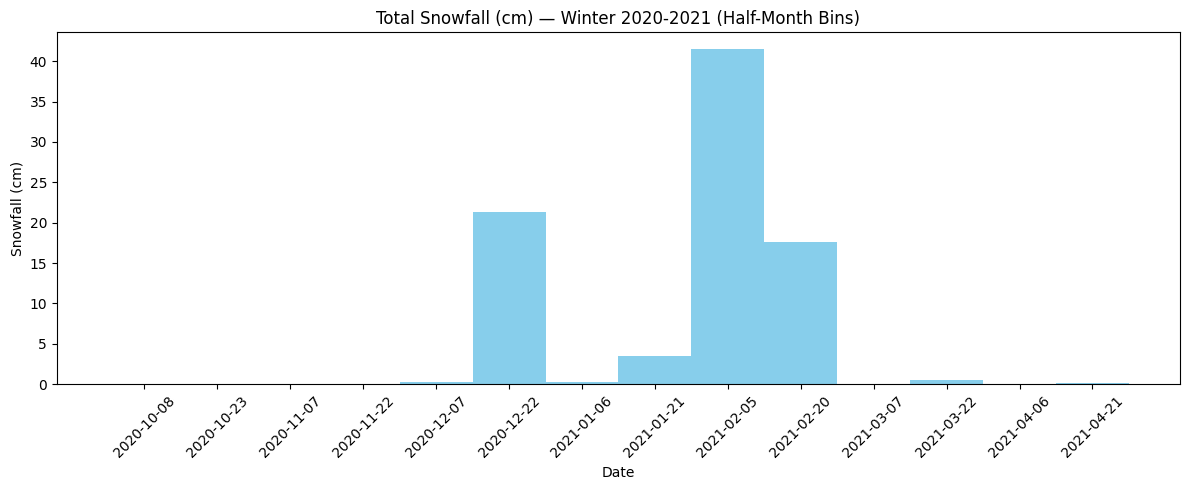

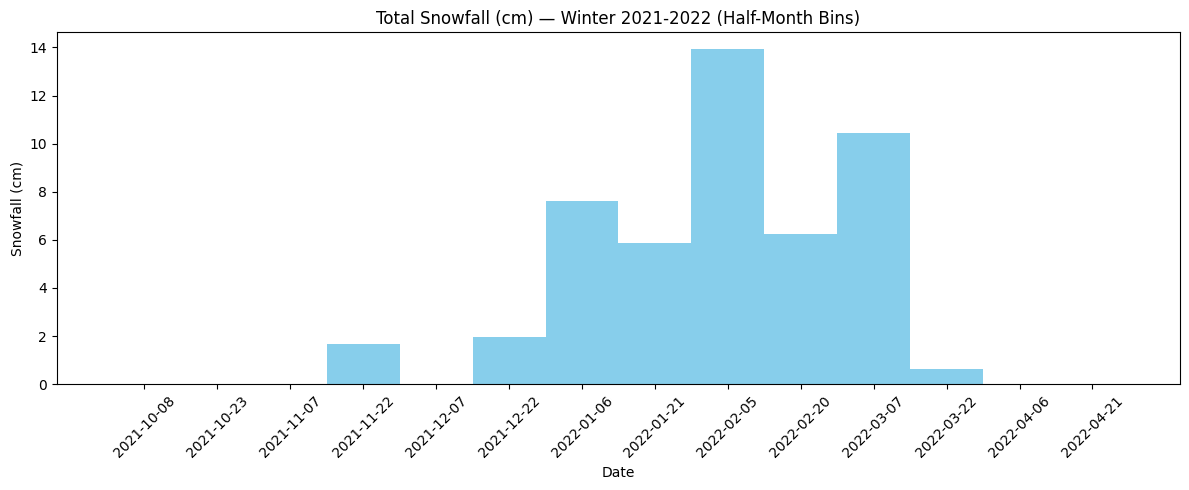

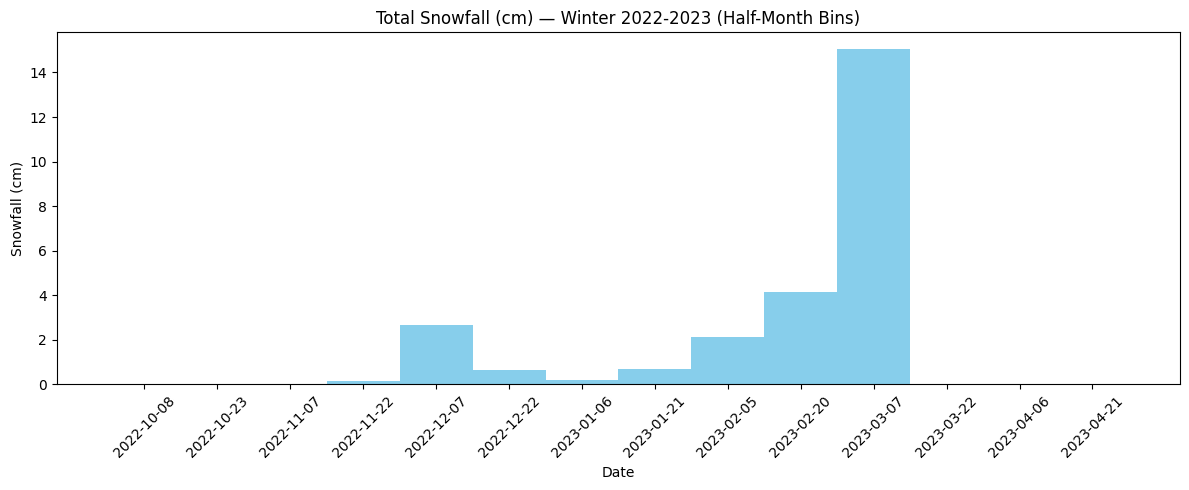

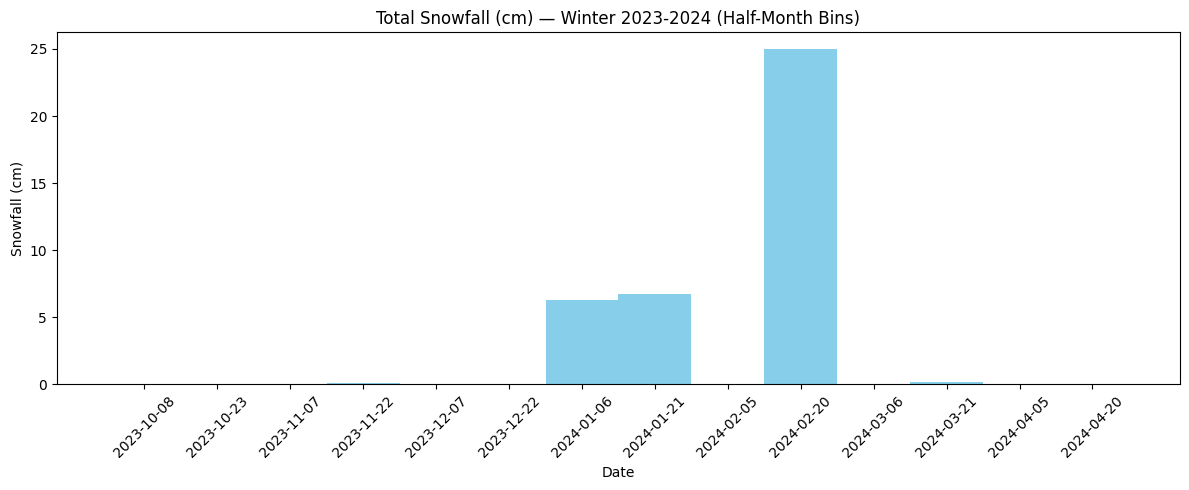

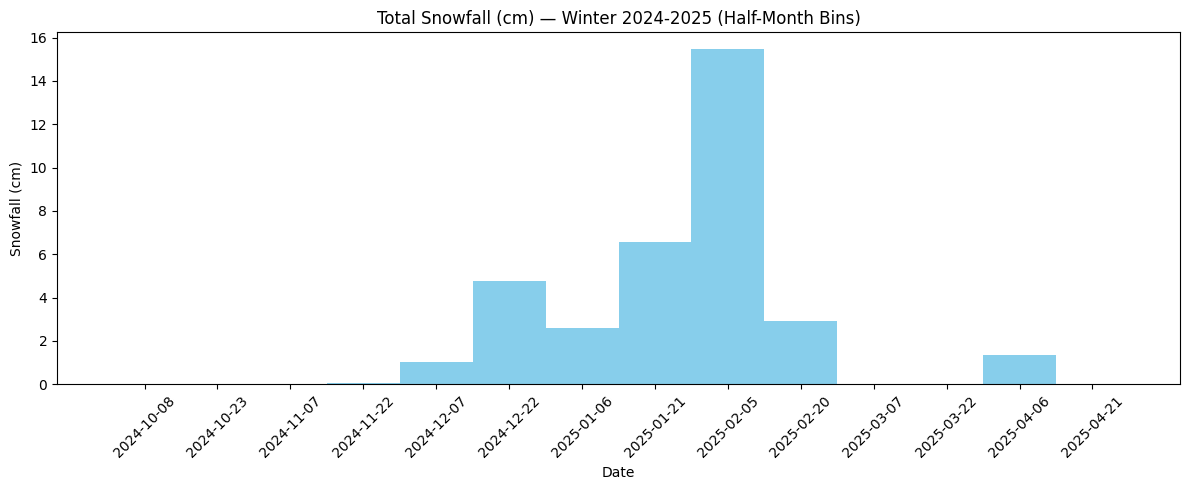

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure datetime and numeric columns
weather['time'] = pd.to_datetime(weather['time'], errors='coerce')
weather['snowfall (cm)'] = pd.to_numeric(weather['snowfall (cm)'], errors='coerce')

# Define seasons: winter 2015–2016 through winter 2024–2025
seasons = [(y-1, y) for y in range(2016, 2025+1)]  # (Oct Y-1 to Apr Y)

for start_year, end_year in seasons:
    start_date = pd.Timestamp(f"{start_year}-10-01")
    end_date = pd.Timestamp(f"{end_year}-05-01")
    
    # Filter snowfall in season
    mask = (weather['time'] >= start_date) & (weather['time'] < end_date)
    df_season = weather[mask].copy()
    
    # Half-month bins
    bins = pd.date_range(start_date, end_date, freq="15D")
    
    # Aggregate snowfall by half-month
    snowfall_sum, _ = np.histogram(df_season['time'], bins=bins, weights=df_season['snowfall (cm)'])
    
    # Bin centers for plotting
    bin_centers = bins[:-1] + np.diff(bins)/2
    
    # Plot
    plt.figure(figsize=(12, 5))
    plt.bar(bin_centers, snowfall_sum, width=np.diff(bins), align="center", color="skyblue")
    plt.xticks(bin_centers, [d.strftime("%Y-%m-%d") for d in bin_centers], rotation=45)
    plt.title(f"Total Snowfall (cm) — Winter {start_year}-{end_year} (Half-Month Bins)")
    plt.xlabel("Date")
    plt.ylabel("Snowfall (cm)")
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd

cscl = pd.read_csv('CSCL.csv')

from shapely import wkt
import numpy as np

# Define station coordinates
stations = np.array([
    [40.703, -74.006],  # 1 City Hall
    [40.597, -73.916],  # 2 Brooklyn Salt Marsh
    [40.649, -73.790],  # 3 JFK
    [40.774, -73.879],  # 4 LGA
    [40.849, -73.878],  # 5 Bronx Zoo
    [40.588, -74.140],  # 6 Staten Island
])

def nearest_station(the_geom_wkt):
    # Parse geometry
    geom = wkt.loads(the_geom_wkt)

    # Extract one representative coordinate
    # (e.g., first coordinate of first LineString)
    if geom.geom_type == "MultiLineString":
        coord = geom.geoms[0].coords[0]
    elif geom.geom_type == "LineString":
        coord = geom.coords[0]
    else:
        return None  # skip invalid geometry

    lat, lon = coord[1], coord[0]  # assuming WKT order is (x, y) = (lon, lat)
    
    # Compute Euclidean distance in degrees
    # (sufficient for NYC-scale comparisons)
    dists = np.sqrt((stations[:,0] - lat)**2 + (stations[:,1] - lon)**2)
    
    # Return station index (1-based)
    return int(np.argmin(dists) + 1)

# Apply to DataFrame
cscl['nearest_station'] = cscl['the_geom'].apply(nearest_station)


In [4]:
from street_normalize import normalize

In [5]:
cscl["normalized_street_name"] = (
    cscl["Borough Code"].astype(str)
    + "-"
    + cscl["Full Street Name"].apply(normalize)
)

In [6]:
import numpy as np
import pandas as pd

# --- 1. Compute median values grouped by type (either POST_TYPE or PRE_TYPE) ---
# Flatten POST_TYPE and PRE_TYPE into a single "type" for median calculation
cscl_types = cscl.copy()
cscl_types["TYPE"] = cscl_types.apply(
    lambda r: r["POST_TYPE"] if pd.notna(r["POST_TYPE"]) else r["PRE_TYPE"], axis=1
)

medians = (
    cscl_types.groupby("TYPE")[["Segment Length", "Street Width"]]
    .median(numeric_only=True)
)

# --- 2. Function to impute by type ---
def impute_by_type(row):
    # Determine the type to use
    types_present = []
    if pd.notna(row["POST_TYPE"]):
        types_present.append(row["POST_TYPE"])
    if pd.notna(row["PRE_TYPE"]):
        types_present.append(row["PRE_TYPE"])
    
    if len(types_present) == 1:
        t = types_present[0]
    elif len(types_present) == 2:
        if types_present[0] == types_present[1]:
            t = types_present[0]
        else:
            t = None  # conflict, cannot impute
    else:
        t = None  # neither populated
    
    if t and t in medians.index:
        if pd.isna(row["Segment Length"]):
            row["Segment Length"] = medians.loc[t, "Segment Length"]
        if pd.isna(row["Street Width"]):
            row["Street Width"] = medians.loc[t, "Street Width"]
    return row

# Apply imputation
cscl = cscl.apply(impute_by_type, axis=1)

# --- 3. Handle rows where type info missing but Segment Length or Street Width is missing ---
mask_missing_type = (cscl["POST_TYPE"].isna() & cscl["PRE_TYPE"].isna()) & (
    cscl["Segment Length"].isna() | cscl["Street Width"].isna()
)
problem_rows = cscl[mask_missing_type].copy()

In [7]:
cscl = cscl[["PHYSICALID", "normalized_street_name", "Segment Length", "Street Width", "nearest_station"]]

In [8]:
# dictionary normalized street name: all physical id's with that street name

name_to_ids = (
    cscl.groupby("normalized_street_name")["PHYSICALID"]
    .apply(list)
    .to_dict()
)

new df called street_weather constructed as follows: it has a "normalized_street_name" column, and columns "DATA 20XX" where DATA is in {temperature, apparent_temperature, snowfall, snow_depth, precipitation, relative_humidity, cloud_cover, wind_gusts_10m, wind_speed_10m}. normalized_street_name goes over all those keys from the dictionary name_to_ids. all other values are computed as the average value across (*) entries in the column whose name begins with that given string (e.g. temperature will be the start of actual string name "temperate_2m (degrees F)" in the corresponding csv) in weather_hourly_i where i is the value in nearest_station in cscl df for that normalized_street_name (might not be unique row, just choose any row with that normalized_street_name), where (*) means cover november 21 20XX-1 to march 20 20XX (e.g. november 21 2015 to march 20 2016 for 20XX = 2016), and 20XX goes from 2016 to 2025

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Config ---
weather_dir = Path(".")  # set to your actual path
YEARS = range(2016, 2026)
VARIABLES = [
    "temperature",
    "apparent_temperature",
    "snowfall",
    "snow_depth",
    "precipitation",
    "relative_humidity",
    "cloud_cover",
    "wind_gusts_10m",
    "wind_speed_10m",
]

# --- Load weather_hourly_i CSVs ---
weather_hourly = {}
for i in range(1, 7):
    f = weather_dir / f"weather_hourly_{i}.csv"
    df = pd.read_csv(f, skiprows=3)
    # Try to find datetime column heuristically
    datetime_col = next(c for c in df.columns if "time" in c.lower())
    df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
    df.rename(columns={datetime_col: "datetime"}, inplace=True)
    weather_hourly[i] = df

# --- Helper to match a variable prefix ---
def get_column(df, prefix):
    prefix = prefix.lower()
    for c in df.columns:
        if c.lower().startswith(prefix):
            return c
    raise KeyError(f"No column starts with '{prefix}' in {df.columns[:8]}...")

# --- Map streets to nearest station ---
station_map = cscl.groupby("normalized_street_name")["nearest_station"].first().to_dict()

records = []

for street, ids in name_to_ids.items():
    if street not in station_map:
        continue

    station_id = station_map[street]
    if station_id not in weather_hourly:
        continue

    wdf = weather_hourly[station_id]

    for year in YEARS:
        start = pd.Timestamp(year - 1, 11, 21)
        end = pd.Timestamp(year, 3, 20, 23, 59)
        sub = wdf.loc[(wdf["datetime"] >= start) & (wdf["datetime"] <= end)]

        if sub.empty:
            continue

        entry = {"normalized_street_name": street}
        for var in VARIABLES:
            col = get_column(wdf, var)
            entry[f"{var} {year}"] = sub[col].mean(skipna=True)
        records.append(entry)

# --- Construct final DataFrame ---
street_weather = pd.DataFrame(records)
street_weather = street_weather.groupby("normalized_street_name").first().reset_index()
